In [1]:
!pip install notebook jupyter ipykernel
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,f1_score, precision_score, recall_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")
print(f" pandas {pd.__version__}")
print(f" numpy  {np.__version__}")
print(f" sklearn{__import__('sklearn').__version__}")

All libraries imported successfully!
 pandas 3.0.2
 numpy  2.4.4
 sklearn1.8.0


In [6]:
#Loading the Dataset
import pandas as pd
Visualisation_analysis = r"C:\Users\lakit\OneDrive\Desktop\planetary transit detection\notebooks\kepler_transit_detection_messy.csv"

df = pd.read_csv(Visualisation_analysis)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              2000 non-null   int64  
 1   kepoi_name         2000 non-null   str    
 2   kepler_name        1165 non-null   str    
 3   koi_disposition    2000 non-null   str    
 4   koi_score          1901 non-null   float64
 5   koi_fpflag_nt      2000 non-null   str    
 6   koi_fpflag_ss      2000 non-null   str    
 7   koi_fpflag_co      2000 non-null   str    
 8   koi_fpflag_ec      2000 non-null   str    
 9   koi_period         1853 non-null   str    
 10  koi_period_err1    1797 non-null   float64
 11  koi_period_err2    1796 non-null   float64
 12  koi_time0bk        1917 non-null   float64
 13  koi_impact         1839 non-null   float64
 14  koi_duration       1850 non-null   str    
 15  koi_duration_err1  1813 non-null   float64
 16  koi_duration_err2  1821 non-null   

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)} out of {len(df.columns)}")
print()
print(missing_df.to_string())

Columns with missing values: 36 out of 43

                   Missing Count  Missing %
kepler_name                  835      41.75
koi_sage                     367      18.35
koi_smass                    205      10.25
koi_period_err2              204      10.20
koi_period_err1              203      10.15
koi_duration_err1            187       9.35
koi_prad_err1                181       9.05
koi_insol                    180       9.00
koi_duration_err2            179       8.95
koi_srad_err2                174       8.70
koi_depth_err2               173       8.65
koi_slogg_err1               168       8.40
koi_teq                      166       8.30
koi_impact                   161       8.05
koi_prad_err2                159       7.95
koi_depth_err1               158       7.90
koi_srad_err1                158       7.90
koi_smet                     156       7.80
koi_slogg_err2               152       7.60
koi_duration                 150       7.50
koi_period                   147 

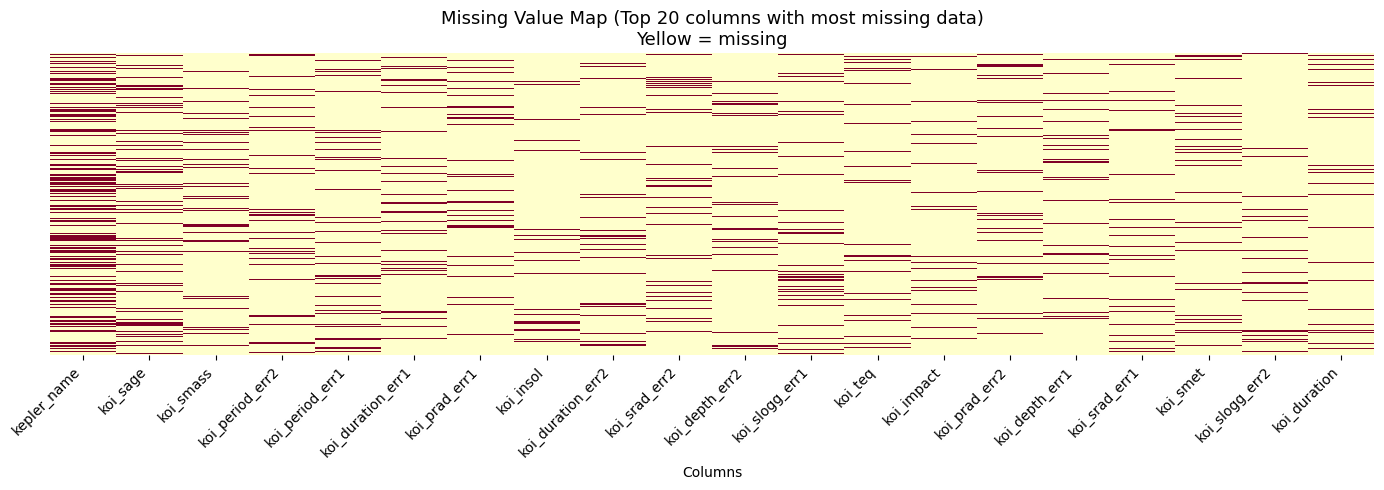

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 5))

top_missing = missing_df.head(20).index.tolist()
sns.heatmap(df[top_missing].isnull(),
            yticklabels=False, cbar=False,
            cmap='YlOrRd', ax=ax)

ax.set_title('Missing Value Map (Top 20 columns with most missing data)\nYellow = missing', fontsize=13)
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
print("Unique values in koi_disposition:")
print(df['koi_disposition'].value_counts().to_string())
print()
print(f"Total unique label variants: {df['koi_disposition'].nunique()}")

Unique values in koi_disposition:
koi_disposition
FALSE POSITIVE    444
CONFIRMED         362
CANDIDATE         204
FP                 80
confirm            80
False Positive     78
false_positive     75
false positive     74
Confirmed          73
CONFIRM            71
FALSE_POSITIVE     71
fp                 70
confirmed          62
Yes                57
Candidate          43
cand               42
Maybe              42
candidate          41
CAND               31

Total unique label variants: 19


In [15]:
print("Physically Impossible Values\n")

neg_period = pd.to_numeric(df['koi_period'], errors='coerce')
print(f"Negative koi_period values     : {(neg_period < 0).sum()}")
score = pd.to_numeric(df['koi_score'], errors='coerce')
print(f"koi_score > 1.0 (impossible)   : {(score > 1).sum()}")

steff = pd.to_numeric(df['koi_steff'], errors='coerce')
print(f"koi_steff <= 0 (impossible)    : {(steff <= 0).sum()}")


ra = pd.to_numeric(df['ra'], errors='coerce')
print(f"RA > 360 (impossible)          : {(ra > 360).sum()}")


dec = pd.to_numeric(df['dec'], errors='coerce')
print(f"Dec > 90 (impossible)          : {(dec > 90).sum()}")

Physically Impossible Values

Negative koi_period values     : 39
koi_score > 1.0 (impossible)   : 33
koi_steff <= 0 (impossible)    : 46
RA > 360 (impossible)          : 21
Dec > 90 (impossible)          : 25


In [18]:
print("String Garbage in Numeric Columns\n")
numeric_cols = ['koi_period', 'koi_duration', 'koi_depth', 'koi_snr',
                'koi_steff', 'koi_teq', 'koi_kepmag', 'koi_prad']

for col in numeric_cols:
    series = df[col].astype(str)
   
    bad = series[pd.to_numeric(series, errors='coerce').isna() & series.notna() & (series != 'nan')]
    if len(bad) > 0:
        print(f"  {col:20s}: {len(bad)} bad values — examples: {bad.unique()[:5].tolist()}")

String Garbage in Numeric Columns

  koi_period          : 49 bad values — examples: ['none', '?', '--', 'na', 'unknown']
  koi_duration        : 45 bad values — examples: ['unknown', 'na', ' ', '--', 'none']
  koi_depth           : 29 bad values — examples: ['--', 'unknown', 'na', '?', ' ']
  koi_snr             : 63 bad values — examples: ['unknown', '?', '--', ' ', 'none']
  koi_steff           : 41 bad values — examples: ['na', 'none', '?', ' ', 'unknown']
  koi_teq             : 38 bad values — examples: ['?', 'unknown', 'none', ' ', '--']
  koi_kepmag          : 44 bad values — examples: ['?', '--', ' ', 'na', 'unknown']
  koi_prad            : 30 bad values — examples: ['unknown', ' ', 'none', '--', 'na']


In [20]:
dup_count = df_raw.duplicated(subset=['kepid']).sum()
print(f"Duplicate kepid entries : {dup_count}")
print()
print(f"Total rows              : {len(df_raw)}")
print(f"Unique kepids           : {df_raw['kepid'].nunique()}")

Duplicate kepid entries : 60

Total rows              : 2000
Unique kepids           : 1940


In [21]:
#3.Data Cleaning
df = df.copy()
print(f"Working copy created: {df.shape}")

Working copy created: (2000, 43)


In [22]:
print("BEFORE cleaning — label distribution:")
print(df['koi_disposition'].value_counts().to_string())
print()
label_map = {
    # CONFIRMED variants
    'CONFIRMED': 'CONFIRMED', 'confirmed': 'CONFIRMED', 'Confirmed': 'CONFIRMED',
    'CONFIRM': 'CONFIRMED', 'confirm': 'CONFIRMED', 'Yes': 'CONFIRMED',
    # FALSE POSITIVE variants
    'FALSE POSITIVE': 'FALSE POSITIVE', 'false positive': 'FALSE POSITIVE',
    'False Positive': 'FALSE POSITIVE', 'FALSE_POSITIVE': 'FALSE POSITIVE',
    'false_positive': 'FALSE POSITIVE', 'FP': 'FALSE POSITIVE', 'fp': 'FALSE POSITIVE',
    # CANDIDATE variants
    'CANDIDATE': 'CANDIDATE', 'candidate': 'CANDIDATE', 'Candidate': 'CANDIDATE',
    'CAND': 'CANDIDATE', 'cand': 'CANDIDATE', 'Maybe': 'CANDIDATE',
}

df['koi_disposition'] = df['koi_disposition'].map(label_map)

# Drop rows where label is still unmapped (NaN)
before = len(df)
df = df.dropna(subset=['koi_disposition'])
print(f"Rows dropped (unmappable label): {before - len(df)}")
print()
print("AFTER cleaning — label distribution:")
print(df['koi_disposition'].value_counts().to_string())

BEFORE cleaning — label distribution:
koi_disposition
FALSE POSITIVE    444
CONFIRMED         362
CANDIDATE         204
FP                 80
confirm            80
False Positive     78
false_positive     75
false positive     74
Confirmed          73
CONFIRM            71
FALSE_POSITIVE     71
fp                 70
confirmed          62
Yes                57
Candidate          43
cand               42
Maybe              42
candidate          41
CAND               31

Rows dropped (unmappable label): 0

AFTER cleaning — label distribution:
koi_disposition
FALSE POSITIVE    892
CONFIRMED         705
CANDIDATE         403


In [23]:
numeric_cols = [
    'koi_period', 'koi_period_err1', 'koi_period_err2',
    'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2',
    'koi_depth', 'koi_depth_err1', 'koi_depth_err2',
    'koi_prad', 'koi_prad_err1', 'koi_prad_err2',
    'koi_sma', 'koi_teq', 'koi_insol',
    'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
    'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2',
    'koi_srad', 'koi_srad_err1', 'koi_srad_err2',
    'koi_smass', 'koi_smet', 'koi_sage',
    'koi_snr', 'koi_score', 'ra', 'dec', 'koi_kepmag'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ String garbage converted to NaN in all numeric columns")
print(f"   Columns processed: {len(numeric_cols)}")

✅ String garbage converted to NaN in all numeric columns
   Columns processed: 34


In [24]:
before = len(df)

# Negative orbital period
df = df[~((df['koi_period'] < 0) & df['koi_period'].notna())]

# Score outside [0, 1]
df = df[~((df['koi_score'] > 1.0) & df['koi_score'].notna())]

# Non-positive stellar temperature
df = df[~((df['koi_steff'] <= 0) & df['koi_steff'].notna())]

# Impossible coordinates
df = df[~((df['ra'] > 360) & df['ra'].notna())]
df = df[~((df['dec'] > 90) & df['dec'].notna())]

removed = before - len(df)
print(f"✅ Impossible values removed: {removed} rows")
print(f"   Remaining rows: {len(df)}")

✅ Impossible values removed: 156 rows
   Remaining rows: 1844


In [25]:
DURATION_MAX_HOURS = 15.0

impossible_duration = (df['koi_duration'] > DURATION_MAX_HOURS) & df['koi_duration'].notna()
n_fixed = impossible_duration.sum()

df.loc[impossible_duration, 'koi_duration'] = df.loc[impossible_duration, 'koi_duration'] / 60.0

print(f"✅ Duration unit correction applied to {n_fixed} rows")
print(f"   (values > {DURATION_MAX_HOURS}h were converted from minutes to hours)")
print()
print(f"Duration range after fix: {df['koi_duration'].min():.2f} — {df['koi_duration'].max():.2f} hours")

✅ Duration unit correction applied to 110 rows
   (values > 15.0h were converted from minutes to hours)

Duration range after fix: 0.61 — 15.00 hours


In [26]:
before = len(df)
df = df.drop_duplicates(subset=['kepid'], keep='first')
removed = before - len(df)
print(f"✅ Duplicate kepids removed: {removed}")
print(f"   Remaining rows: {len(df)}")

✅ Duplicate kepids removed: 53
   Remaining rows: 1791


In [28]:
import numpy as np
flag_cols = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

for col in flag_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')           # coerce 'Y','N' to NaN
        df[col] = df[col].where(df[col].isin([0, 1]), other=np.nan) # keep only 0 or 1
        df[col] = df[col].fillna(0).astype(int)                     # fill NaN with 0 (assume no flag)

print("✅ False positive flags standardised to binary (0/1)")
for col in flag_cols:
    print(f"   {col}: {df[col].value_counts().to_dict()}")

✅ False positive flags standardised to binary (0/1)
   koi_fpflag_nt: {0: 1246, 1: 545}
   koi_fpflag_ss: {0: 1395, 1: 396}
   koi_fpflag_co: {0: 1299, 1: 492}
   koi_fpflag_ec: {0: 1473, 1: 318}


In [29]:
print("Missing values BEFORE imputation:")
print(df[numeric_cols].isnull().sum()[df[numeric_cols].isnull().sum() > 0].to_string())
print()

# Drop columns with > 40% missing (too much to impute reliably)
threshold = 0.40
cols_to_drop = [c for c in df.columns if c in numeric_cols and
                df[c].isnull().mean() > threshold]
print(f"Columns dropped (> 40% missing): {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Impute remaining columns with column median
remaining_numeric = [c for c in numeric_cols if c in df.columns]
for col in remaining_numeric:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print()
print("✅ Missing values handled:")
print(f"   Columns dropped (>40% missing) : {len(cols_to_drop)}")
print(f"   Remaining columns imputed with median: {len(remaining_numeric) - len(cols_to_drop)}")
print()
print(f"Missing values AFTER imputation: {df[remaining_numeric].isnull().sum().sum()}")

Missing values BEFORE imputation:
koi_period           181
koi_period_err1      184
koi_period_err2      186
koi_time0bk           76
koi_impact           141
koi_duration         173
koi_duration_err1    165
koi_duration_err2    154
koi_depth            145
koi_depth_err1       146
koi_depth_err2       154
koi_prad             159
koi_prad_err1        162
koi_prad_err2        155
koi_sma              117
koi_teq              181
koi_insol            166
koi_steff            154
koi_steff_err1       118
koi_steff_err2       104
koi_slogg             86
koi_slogg_err1       153
koi_slogg_err2       132
koi_srad              73
koi_srad_err1        140
koi_srad_err2        157
koi_smass            188
koi_smet             144
koi_sage             330
koi_snr              161
koi_score             85
ra                    29
dec                   31
koi_kepmag           131

Columns dropped (> 40% missing): []

✅ Missing values handled:
   Columns dropped (>40% missing) : 0
   Remaining c

In [33]:
print("=" * 50)
print("CLEANING SUMMARY")

print(f"Original rows        : {len(df_raw):>6}")
print(f"After cleaning       : {len(df):>6}")
print(f"Rows removed         : {len(df_raw) - len(df):>6}")
print()
print("Final class distribution:")
print(df['koi_disposition'].value_counts().to_string())
print()
print(f"Final shape: {df.shape}")
print("=" * 50)
# Save clean version
df.to_csv('kepler_cleaned.csv', index=False)

CLEANING SUMMARY
Original rows        :   2000
After cleaning       :   1791
Rows removed         :    209

Final class distribution:
koi_disposition
FALSE POSITIVE    802
CONFIRMED         631
CANDIDATE         358

Final shape: (1791, 43)


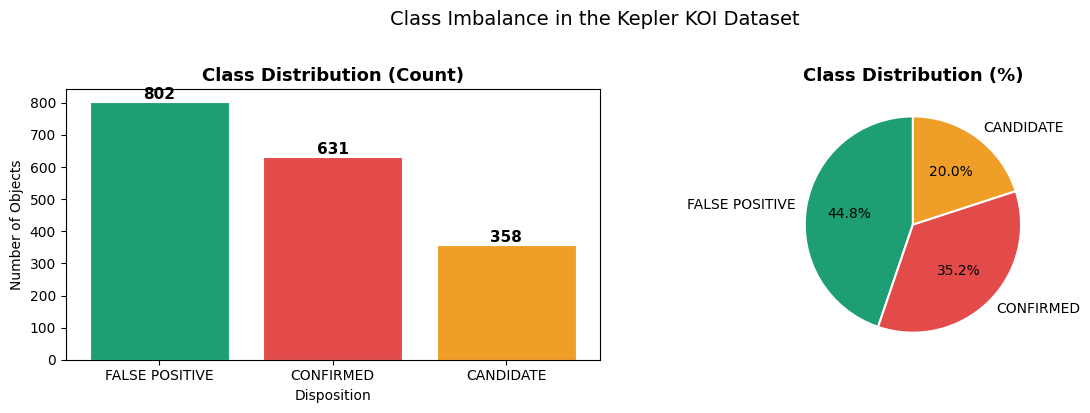

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['koi_disposition'].value_counts()
colors = ['#1D9E75', '#E24B4A', '#EF9F27']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disposition')
axes[0].set_ylabel('Number of Objects')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance in the Kepler KOI Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

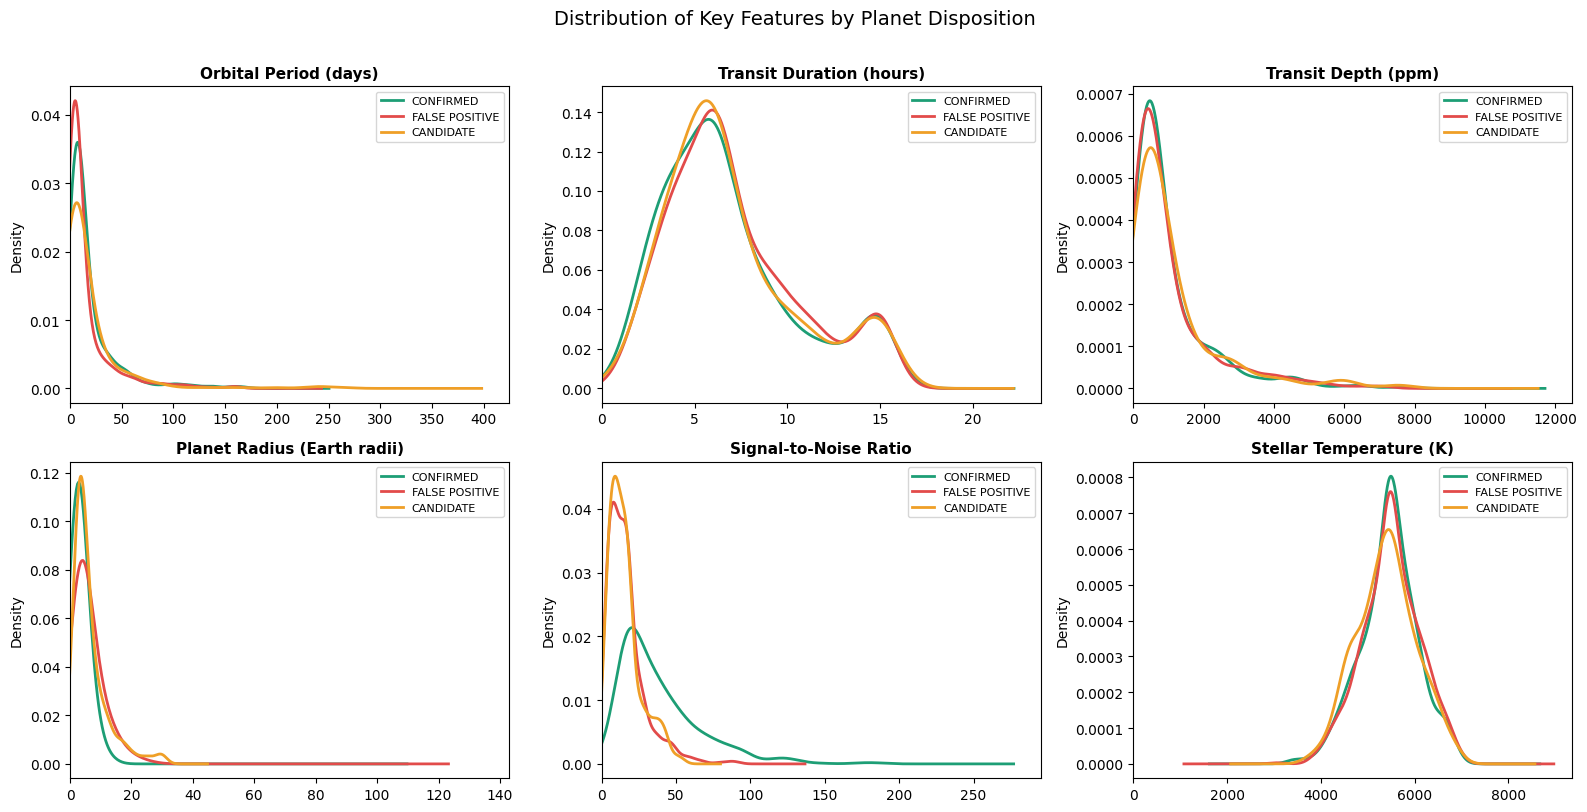

In [39]:
features_to_plot = {
    'koi_period'  : 'Orbital Period (days)',
    'koi_duration': 'Transit Duration (hours)',
    'koi_depth'   : 'Transit Depth (ppm)',
    'koi_prad'    : 'Planet Radius (Earth radii)',
    'koi_snr'     : 'Signal-to-Noise Ratio',
    'koi_steff'   : 'Stellar Temperature (K)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

palette = {'CONFIRMED': '#1D9E75', 'FALSE POSITIVE': '#E24B4A', 'CANDIDATE': '#EF9F27'}

for ax, (col, label) in zip(axes, features_to_plot.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue

    for disposition, color in palette.items():
        subset = df[df['koi_disposition'] == disposition][col].dropna()
        # Clip extreme outliers for visualisation (99th percentile)
        upper = subset.quantile(0.99)
        subset = subset[subset <= upper]
        subset.plot.kde(ax=ax, label=disposition, color=color, linewidth=2)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(left=0)

plt.suptitle('Distribution of Key Features by Planet Disposition', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

Features available for ML: 14
['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_impact', 'koi_snr', 'koi_score', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_teq', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co']


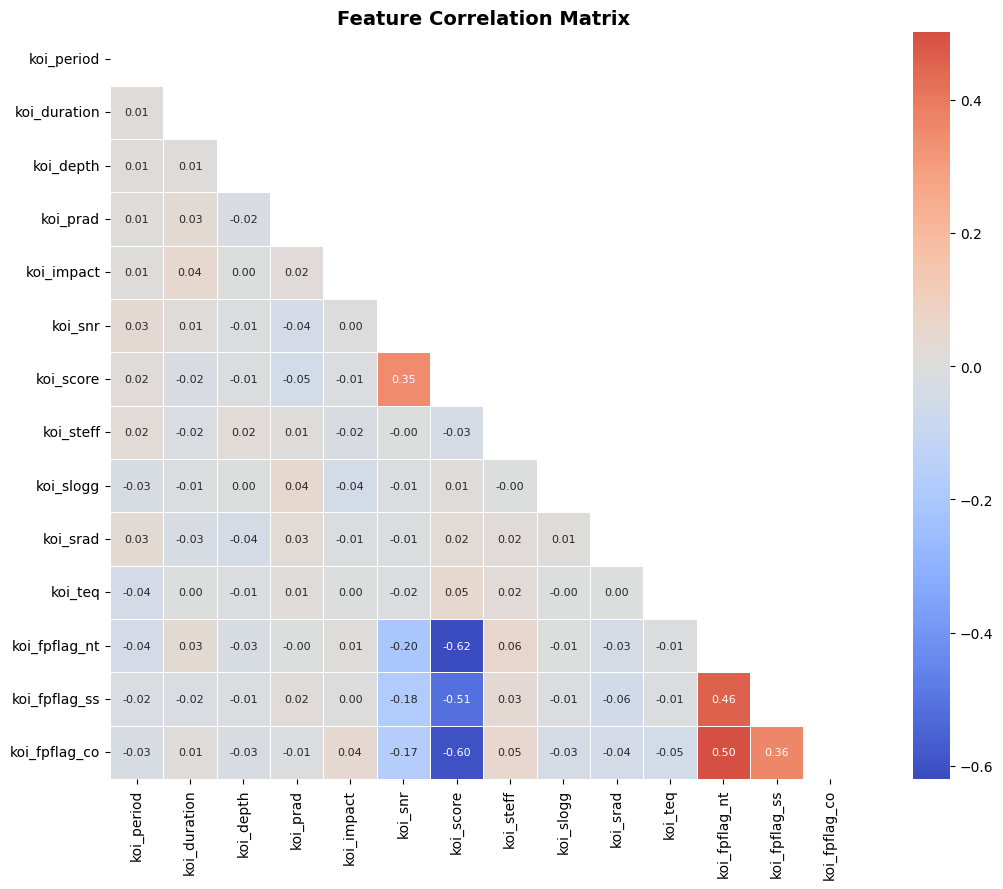

In [41]:
ml_features = [
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad',
    'koi_impact', 'koi_snr', 'koi_score',
    'koi_steff', 'koi_slogg', 'koi_srad',
    'koi_teq', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co'
]

# Keep only features that exist after cleaning
ml_features = [f for f in ml_features if f in df.columns]
print(f"Features available for ML: {len(ml_features)}")
print(ml_features)

corr = df[ml_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [42]:
missing_after = df[ml_features].isnull().mean() * 100
missing_after = missing_after[missing_after > 0].sort_values(ascending=True)

if len(missing_after) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_after) * 0.4)))
    missing_after.plot.barh(ax=ax, color='#378ADD', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Remaining Missing Values After Cleaning', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig5_missing_after.png', bbox_inches='tight')
    plt.show()
else:
    print("No missing values remain in the selected ML features!")

No missing values remain in the selected ML features!


TypeError: Axes.boxplot() got an unexpected keyword argument 'Tick_labels'. Did you mean 'tick_labels'?

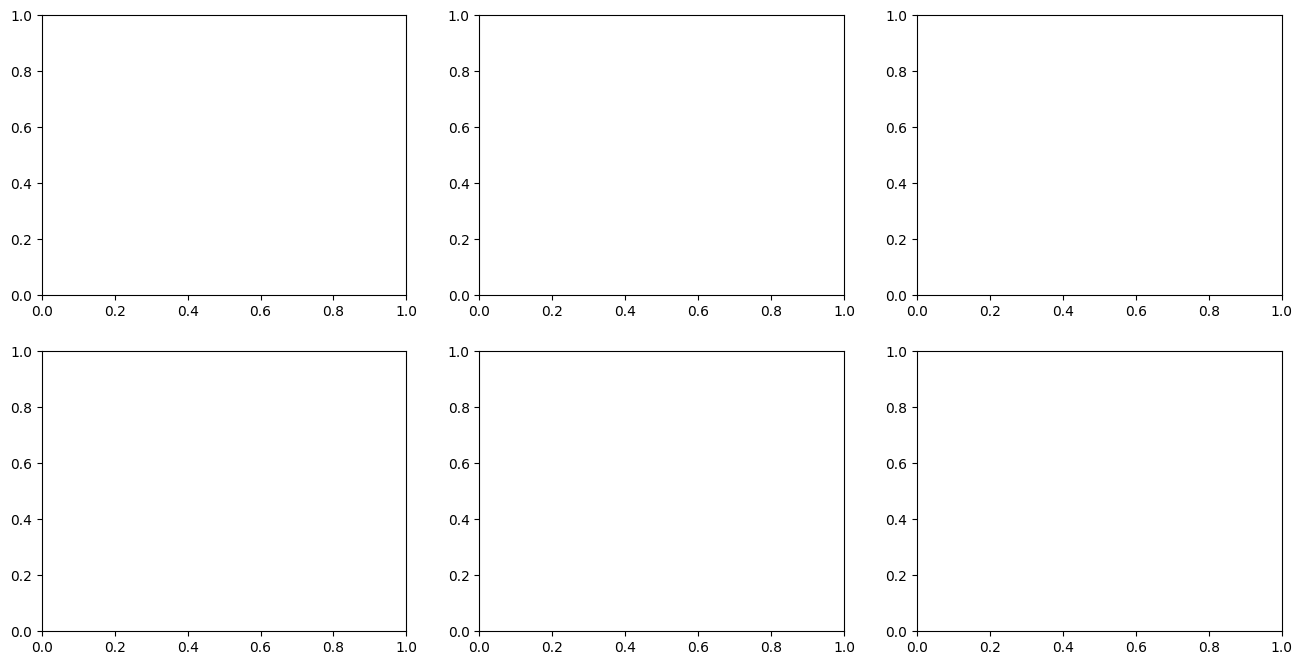

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
plot_cols = ['koi_period', 'koi_snr', 'koi_depth', 'koi_prad', 'koi_steff', 'koi_srad']
plot_cols = [c for c in plot_cols if c in df.columns]

for ax, col in zip(axes, plot_cols):
    data_by_class = [
        df[df['koi_disposition'] == d][col].dropna().values
        for d in ['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
    ]
    bp = ax.boxplot(data_by_class,
                    patch_artist=True,
                    Tick_labels=['CONF', 'FP', 'CAND'],
                    showfliers=False)
    colors_bp = ['#1D9E75', '#E24B4A', '#EF9F27']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Figure 4 — Boxplots by Class (Outliers Hidden for Clarity)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig6_boxplots.png', bbox_inches='tight')
plt.show()

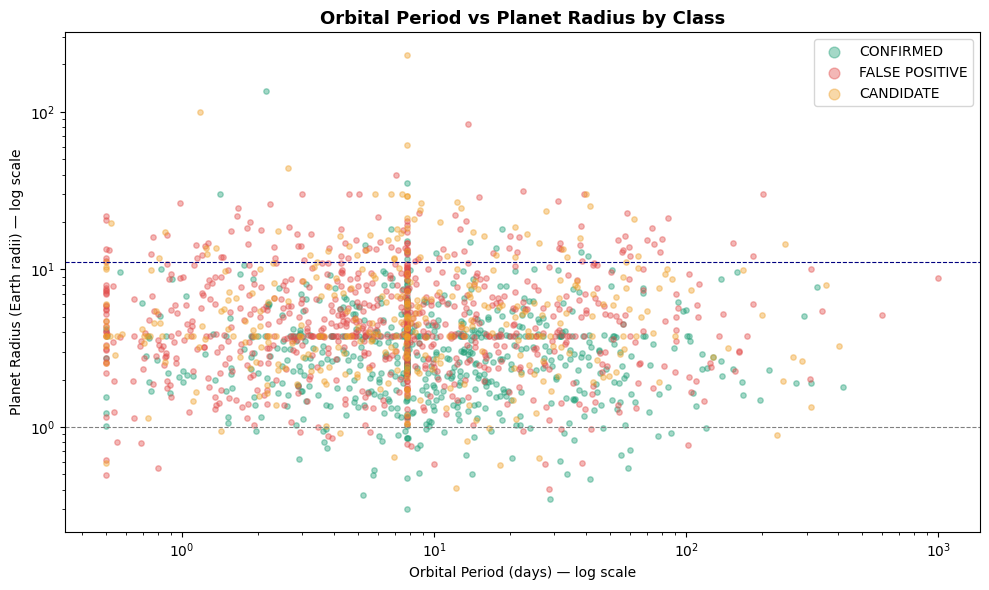

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'CONFIRMED': '#1D9E75', 'FALSE POSITIVE': '#E24B4A', 'CANDIDATE': '#EF9F27'}
for disposition, color in palette.items():
    subset = df[df['koi_disposition'] == disposition]
    ax.scatter(subset['koi_period'], subset['koi_prad'],
               alpha=0.4, s=15, color=color, label=disposition)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Orbital Period (days) — log scale')
ax.set_ylabel('Planet Radius (Earth radii) — log scale')
ax.set_title('Orbital Period vs Planet Radius by Class', fontsize=13, fontweight='bold')
ax.legend(markerscale=2)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, label='1 Earth radius')
ax.axhline(y=11.2, color='navy', linestyle='--', linewidth=0.8, label='1 Jupiter radius')
plt.tight_layout()
plt.savefig('fig7_period_vs_radius.png', bbox_inches='tight')
plt.show()

In [57]:
#Preparing data for ML modeling

df_ml = df[ml_features + ['koi_disposition']].copy()

df_ml['target'] = (df_ml['koi_disposition'] == 'CONFIRMED').astype(int)
df_ml = df_ml.drop(columns=['koi_disposition'])

print("Binary target distribution:")
print(df_ml['target'].value_counts().rename({1: 'CONFIRMED (1)', 0: 'NOT CONFIRMED (0)'}).to_string())
print()
print(f"Positive class ratio: {df_ml['target'].mean():.2%}")
print("Only {:.1f}% of samples are confirmed planets.".format(df_ml['target'].mean()*100))
print("This is the imbalance we need to fix!")

Binary target distribution:
target
NOT CONFIRMED (0)    1160
CONFIRMED (1)         631

Positive class ratio: 35.23%
Only 35.2% of samples are confirmed planets.
This is the imbalance we need to fix!


In [58]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
X = df_ml.drop(columns=['target'])
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  
)

print(f"Training set : {len(X_train)} samples  ({y_train.mean():.2%} positive)")
print(f"Test set     : {len(X_test)}  samples  ({y_test.mean():.2%} positive)")


Training set : 1432 samples  (35.27% positive)
Test set     : 359  samples  (35.10% positive)


In [53]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)         

print("✅ Features scaled (StandardScaler)")
print(f"   Training set mean  ≈ {X_train_scaled.mean():.4f}  (should be ~0)")
print(f"   Training set std   ≈ {X_train_scaled.std():.4f}  (should be ~1)")

✅ Features scaled (StandardScaler)
   Training set mean  ≈ -0.0000  (should be ~0)
   Training set std   ≈ 1.0000  (should be ~1)


In [60]:

from imblearn.over_sampling import SMOTE
print("Before SMOTE:")
print(pd.Series(y_train).value_counts().rename({1:'CONFIRMED',0:'NOT CONFIRMED'}).to_string())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print()
print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts().rename({1:'CONFIRMED',0:'NOT CONFIRMED'}).to_string())
print()
print(f"Training set size before SMOTE : {len(X_train_scaled)}")
print(f"Training set size after  SMOTE : {len(X_train_sm)}")

Before SMOTE:
target
NOT CONFIRMED    927
CONFIRMED        505

After SMOTE:
target
CONFIRMED        927
NOT CONFIRMED    927

Training set size before SMOTE : 1432
Training set size after  SMOTE : 1854


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42, class_weight='balanced', n_jobs=-1),

    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True, random_state=42, class_weight='balanced'),

    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric='logloss', verbosity=0),
}

print("Classifiers defined:")
for name in classifiers:
    print(f"   • {name}")

Classifiers defined:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • SVM
   • XGBoost


In [70]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,f1_score, precision_score, recall_score, RocCurveDisplay)
results = {}

for name, clf in classifiers.items():
    print(f"Training {name}", end=' ')

    row = {'Classifier': name}

    # --- WITHOUT SMOTE ---
    clf.fit(X_train_scaled, y_train)
    y_pred_no = clf.predict(X_test_scaled)
    y_prob_no = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None

    row['F1 (no SMOTE)']        = round(f1_score(y_test, y_pred_no, zero_division=0), 4)
    row['Precision (no SMOTE)'] = round(precision_score(y_test, y_pred_no, zero_division=0), 4)
    row['Recall (no SMOTE)']    = round(recall_score(y_test, y_pred_no, zero_division=0), 4)
    row['AUC (no SMOTE)']       = round(roc_auc_score(y_test, y_prob_no) if y_prob_no is not None else 0, 4)

    # --- WITH SMOTE ---
    clf.fit(X_train_sm, y_train_sm)
    y_pred_sm = clf.predict(X_test_scaled)
    y_prob_sm = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None

    row['F1 (SMOTE)']        = round(f1_score(y_test, y_pred_sm, zero_division=0), 4)
    row['Precision (SMOTE)'] = round(precision_score(y_test, y_pred_sm, zero_division=0), 4)
    row['Recall (SMOTE)']    = round(recall_score(y_test, y_pred_sm, zero_division=0), 4)
    row['AUC (SMOTE)']       = round(roc_auc_score(y_test, y_prob_sm) if y_prob_sm is not None else 0, 4)

    results[name] = row
    print("done")

results_df = pd.DataFrame(results.values())
print()

print(results_df.to_string(index=False))


Training Logistic Regression done
Training Decision Tree done
Training Random Forest done
Training SVM done
Training XGBoost done

         Classifier  F1 (no SMOTE)  Precision (no SMOTE)  Recall (no SMOTE)  AUC (no SMOTE)  F1 (SMOTE)  Precision (SMOTE)  Recall (SMOTE)  AUC (SMOTE)
Logistic Regression         0.9457                0.9242             0.9683          0.9924      0.9569             0.9457          0.9683       0.9920
      Decision Tree         0.9606                0.9531             0.9683          0.9712      0.9262             0.9576          0.8968       0.9436
      Random Forest         0.9565                0.9528             0.9603          0.9957      0.9565             0.9528          0.9603       0.9946
                SVM         0.9644                0.9606             0.9683          0.9920      0.9402             0.9440          0.9365       0.9903
            XGBoost         0.9520                0.9597             0.9444          0.9958      0.9478      

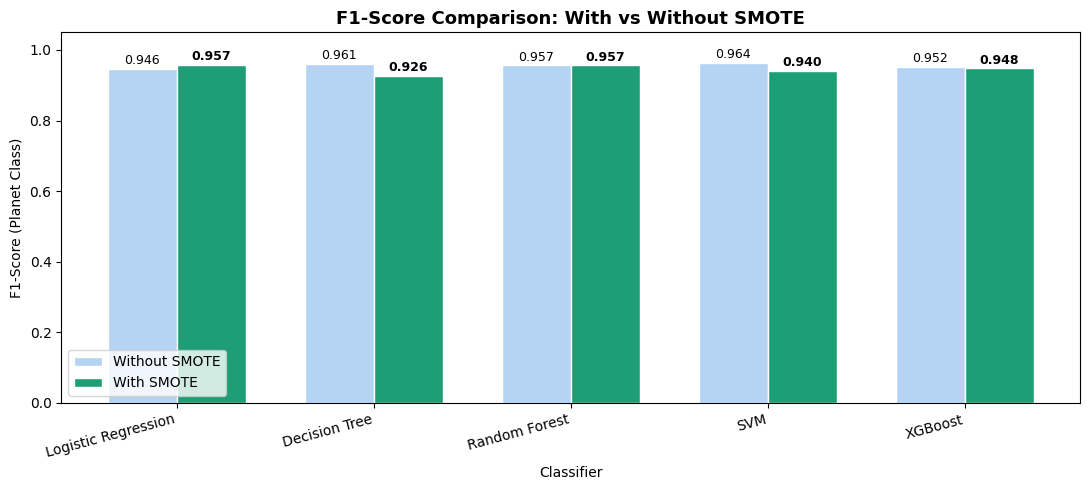

In [81]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['F1 (no SMOTE)'], w,
               label='Without SMOTE', color='#B5D4F4', edgecolor='white')
bars2 = ax.bar(x + w/2, results_df['F1 (SMOTE)'], w,
               label='With SMOTE',    color='#1D9E75', edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Classifier')
ax.set_ylabel('F1-Score (Planet Class)')
ax.set_title('F1-Score Comparison: With vs Without SMOTE', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Classifier'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig8_f1_comparison.png', bbox_inches='tight')
plt.show()

c:\Users\lakit\OneDrive\Desktop\planetary transit detection\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\lakit\OneDrive\Desktop\planetary transit detection\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\lakit\OneDrive\Desktop\planetary transit detection\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\lakit\OneDrive\Desktop\planetary transit detection\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in

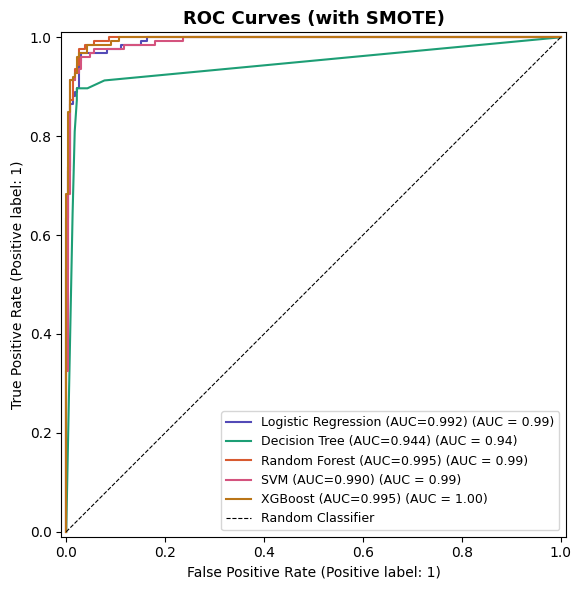

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ['#534AB7', '#1D9E75', '#D85A30', '#D4537E', '#BA7517']

for (name, clf), color in zip(classifiers.items(), colors_roc):
    clf.fit(X_train_sm, y_train_sm)
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        RocCurveDisplay.from_predictions(
            y_test, y_prob, name=f"{name} (AUC={auc:.3f})",
            ax=ax, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Classifier')
ax.set_title('ROC Curves (with SMOTE)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

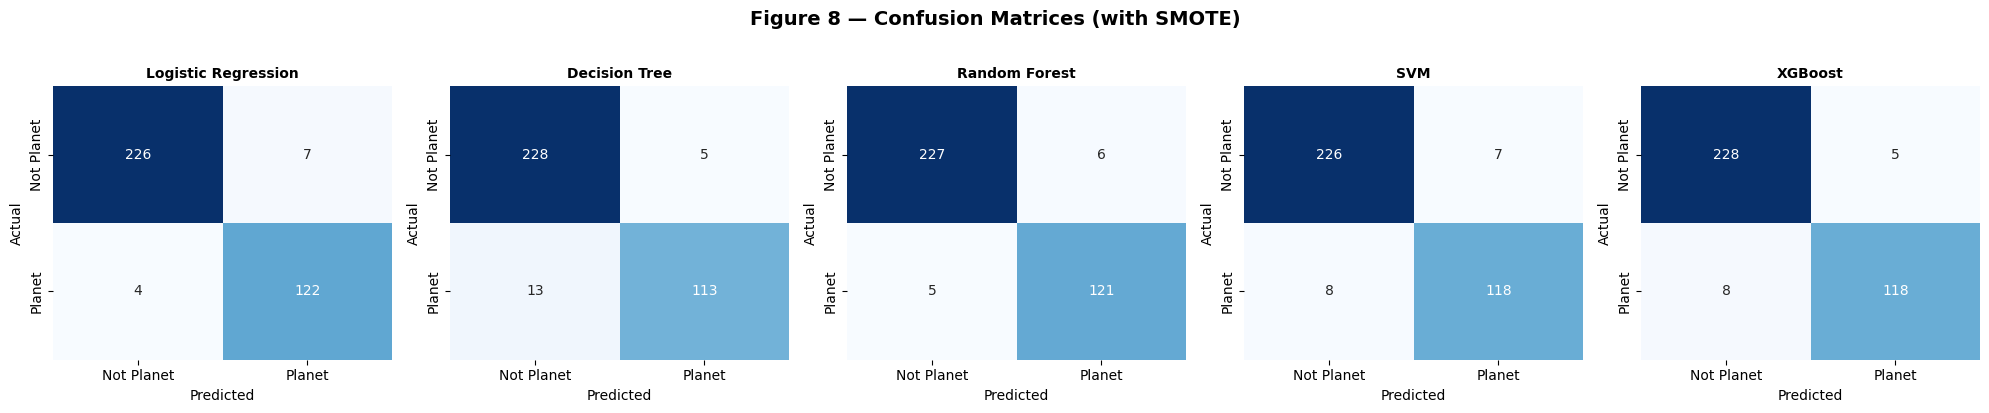

In [85]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, clf) in zip(axes, classifiers.items()):
    clf.fit(X_train_sm, y_train_sm)
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Planet', 'Planet'],
                yticklabels=['Not Planet', 'Planet'],
                cbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Figure 8 — Confusion Matrices (with SMOTE)', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', bbox_inches='tight')
plt.show()


In [86]:
best_row = results_df.loc[results_df['F1 (SMOTE)'].idxmax()]
best_name = best_row['Classifier']
print(f"Best classifier (highest F1 with SMOTE): {best_name}")
print(f"F1 Score: {best_row['F1 (SMOTE)']}")

Best classifier (highest F1 with SMOTE): Logistic Regression
F1 Score: 0.9569


In [91]:
import shap
best_clf = classifiers[best_name]
best_clf.fit(X_train_sm, y_train_sm)

try:
    explainer = shap.TreeExplainer(best_clf)
    shap_values = explainer.shap_values(X_test_scaled)

    if isinstance(shap_values, list):
        sv = shap_values[1]   # take class 1 (planet) SHAP values
    else:
        sv = shap_values
    print(f"✅ SHAP TreeExplainer used (fast, exact)")
except Exception:
    explainer = shap.KernelExplainer(best_clf.predict_proba, X_train_sm[:100])
    shap_values = explainer.shap_values(X_test_scaled[:100])
    sv = shap_values[1]
    print("✅ SHAP KernelExplainer used (approximate)")

print(f"SHAP values shape: {np.array(sv).shape}")

  0%|          | 0/100 [00:00<?, ?it/s]

✅ SHAP KernelExplainer used (approximate)
SHAP values shape: (14, 2)


In [101]:
feature_names = list(X.columns)

mean_shap = np.abs(sv.values).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    shap_df['Feature'],
    shap_df['Mean |SHAP|']
)

top3 = shap_df.nlargest(3, 'Mean |SHAP|')['Feature'].values

for i, feat in enumerate(shap_df['Feature']):
    if feat in top3:
        bars[i].set_color('black')

ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(
    f'Figure 9 — SHAP Feature Importance ({best_name})\n'
    'Highlighted: Top 3 most important features'
)

plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'values'